In [155]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [156]:
# Load the dataset
df = pd.read_csv('/Users/shivanirawat/Desktop/Titanic Survival Analysis (EDA)/train.csv')
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [157]:
# 1. Inspect data
print("First 5 rows:\n", df.head())
print("\nData Info:\n")
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())

First 5 rows:
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   Na

In [158]:
# 2. Data Cleaning
# Fill missing values 
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
print("\nMissing Values after imputation:\n", df.isnull().sum())


Missing Values after imputation:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


/var/folders/4x/083nxg790kddspnh47ylqc3m0000gn/T/ipykernel_1500/2794590244.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df['Age'].median(), inplace=True)
/var/folders/4x/083nxg790kddspnh47ylqc3m0000gn/T/ipykernel_1500/2794590244.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

In [159]:
# Drop Cabin column (too many missing values)
df.drop(columns=['Cabin'], inplace=True)
print("\nData after dropping 'Cabin' column:\n", df.head())


Data after dropping 'Cabin' column:
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Embarked  
0      0         A/5 21171   7.2500        S  
1      0          PC 17599  71.2833        C  
2      0  STON/O2. 3101282   7.9250        S  
3      0            113803  53.1000        S  
4      0            373450   8.0500        S  


In [160]:
print(df['Age'].describe())

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64


In [161]:
# 3. Feature Engineering (Age Buckets)
df['Age_group'] = pd.cut(
    df['Age'],
    bins=[0, 12, 20, 60, 100],
    labels=['Child', 'Teen', 'Adult', 'Senior']
)
print(labels := df['Age_group'].value_counts())

Age_group
Adult     513
Teen      110
Child      69
Senior     22
Name: count, dtype: int64


In [162]:
# 4. Survival Rate Analysis (%)
print("\nSurvival Rate by Gender:\n", df.groupby('Sex')['Survived'].mean())

print("\nSurvival Rate by Class:\n", df.groupby('Pclass')['Survived'].mean())

print("\nSurvival Rate by Age Group:\n", df.groupby('Age_group')['Survived'].mean())


Survival Rate by Gender:
 Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival Rate by Class:
 Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Survival Rate by Age Group:
 Age_group
Child     0.579710
Teen      0.381818
Adult     0.395712
Senior    0.227273
Name: Survived, dtype: float64


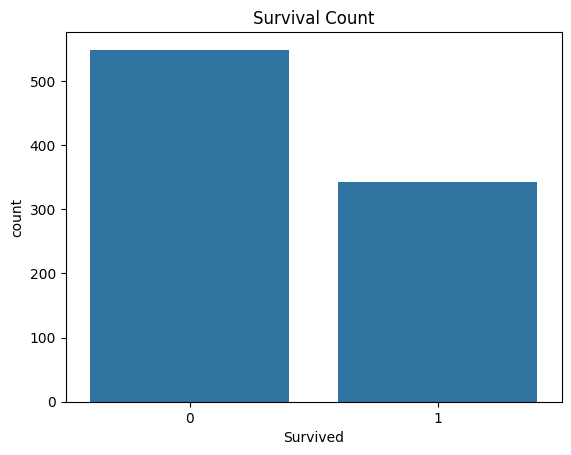

In [163]:
# 5. Visualizations
# Survival Count
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.savefig('plots/Survival_Count.png')
plt.show()

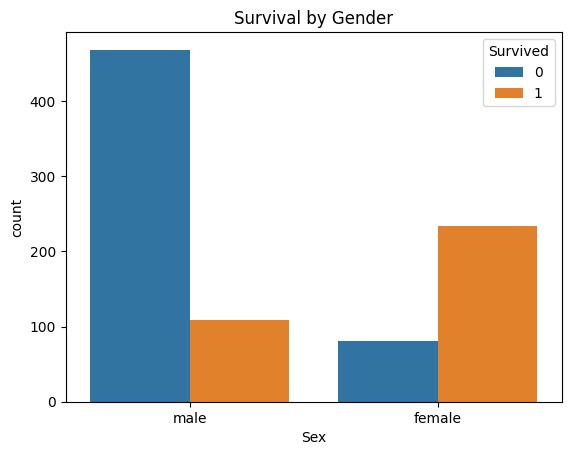

In [164]:
# Survival by Gender
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival by Gender')
plt.savefig('plots/Survival_by_Gender.png')
plt.show()

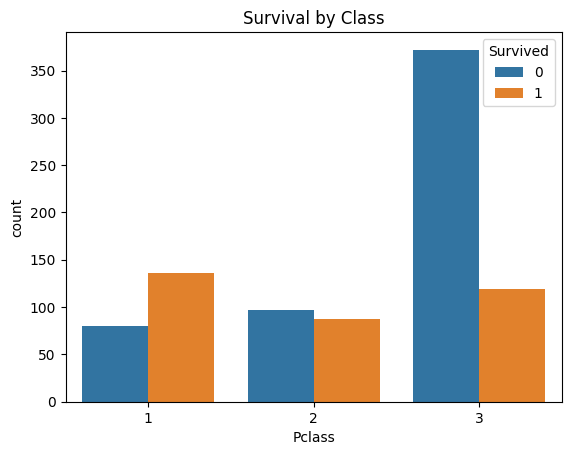

In [165]:
# Survival By Class
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival by Class')
plt.savefig('plots/Survival_by_Class.png')
plt.show()

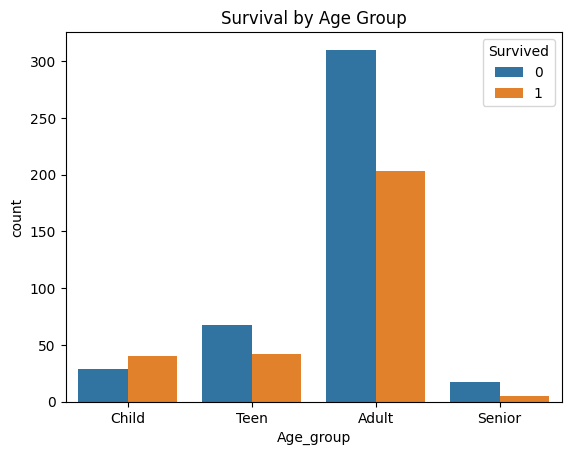

In [166]:
# Survival by Age Group
sns.countplot(x='Age_group', hue='Survived', data=df)
plt.title('Survival by Age Group')
plt.savefig('plots/Survival_by_Age_Group.png')
plt.show()

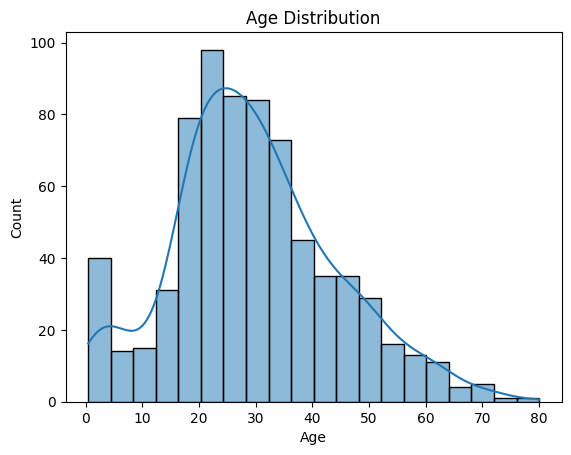

In [167]:
# Age Distribution
sns.histplot(df['Age'], kde=True)
plt.title('Age Distribution')
plt.savefig('plots/Age_Distribution.png')
plt.show()

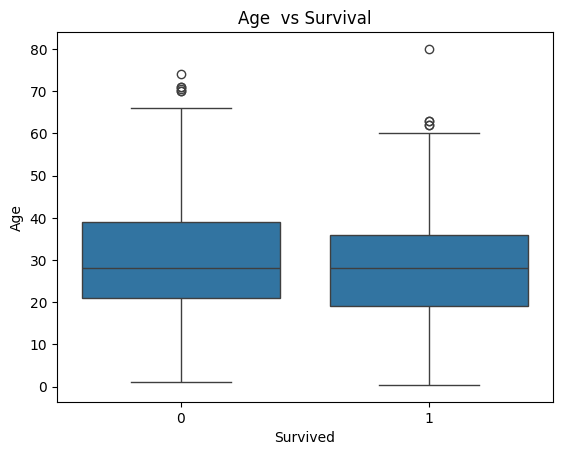

In [168]:
# Boxplot
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Age  vs Survival')
plt.savefig('plots/Age_vs_Survival.png')
plt.show()

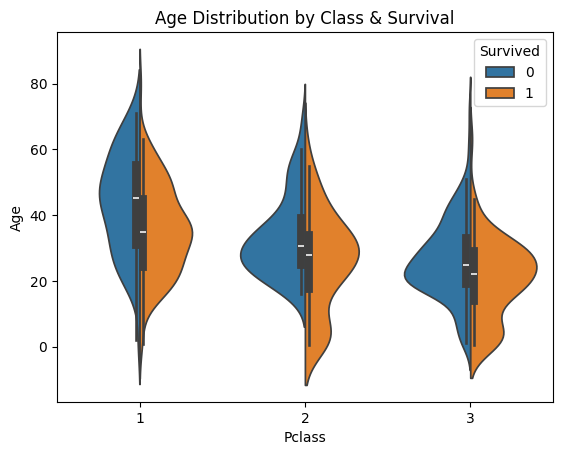

In [169]:
# Violin Plot
sns.violinplot(x='Pclass', y='Age', hue='Survived', data=df, split=True)
plt.title("Age Distribution by Class & Survival")
plt.savefig('plots/Age_Distribution_by_Class_and_Survival.png')
plt.show()